In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F
MAX_WORDS = 120
WORDS_PER_LINE = 8
END_TOKEN = "<EOS>"


In [2]:
# -------------------------
# 1. Reproducibility + Device
# -------------------------

import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
# -------------------------
# 2. Special Tokens
# -------------------------

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

word2idx = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}
idx2word = {idx: token for token, idx in word2idx.items()}

PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]
SOS_IDX = word2idx[SOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]

print(word2idx)

{'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}


In [4]:
# -------------------------
# 3. Model Hyperparameters
# -------------------------

WORD_DIM = 300
GLOBAL_MELODY_DIM = 7
ALIGNED_MELODY_DIM = 4

HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.2

BATCH_SIZE = 16
SEQ_LEN = 30
LEARNING_RATE = 1e-3
EPOCHS = 8

# LSTM model

In [5]:
# -------------------------
# 4. LSTM Model
# -------------------------

class LyricsLSTM(nn.Module):
    def __init__(
        self,
        word_dim,
        melody_dim,
        hidden_dim,
        vocab_size,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        self.word_dim = word_dim
        self.melody_dim = melody_dim

        self.lstm = nn.LSTM(
            input_size=word_dim + melody_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, word_vectors, melody_features=None):
        if self.melody_dim > 0:
            if melody_features is None:
                raise ValueError("melody_features is required for this model")
            x = torch.cat([word_vectors, melody_features], dim=-1)
        else:
            x = word_vectors

        out, _ = self.lstm(x)
        out = self.dropout(out)
        logits = self.fc(out)

        return logits

#  Load Lyrics CSV


In [6]:
import pandas as pd

CSV_PATH = r"D:\Masters Study\2ndyear\Deep_Learning\DL-Assignment-3\Data\Archive (1)\lyrics_train_set.csv"

df = pd.read_csv(CSV_PATH, header=None)

df = df.iloc[:, :3]
df.columns = ["artist", "title", "lyrics"]

print(df.head())
print(df.columns)
print(df.shape)

           artist                           title  \
0      elton john              candle in the wind   
1  gerry rafferty                    baker street   
2  gerry rafferty             right down the line   
3     2 unlimited                    tribal dance   
4     2 unlimited  let the beat control your body   

                                              lyrics  
0  goodbye norma jean & though i never knew you a...  
1  winding your way down on baker street & lite i...  
2  you know i need your love & you've got that ho...  
3  come on check it out ya'll & (come on come on!...  
4  let the beat control your body & let the beat ...  
Index(['artist', 'title', 'lyrics'], dtype='object')
(600, 3)


In [7]:
# -------------------------
# 7. Text Cleaning
# -------------------------

import re

def clean_text(text):
    text = text.lower()

    # replace & with newline marker
    text = text.replace("&", " <NEWLINE> ")

    text = re.sub(r"[^a-zA-Z0-9\s'<NEWLINE>]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
df["clean_lyrics"] = df["lyrics"].apply(clean_text)

print(df["clean_lyrics"].iloc[0][:500])

goodbye norma jean <NEWLINE> though i never knew you at all <NEWLINE> you had the grace to hold yourself <NEWLINE> while those around you crawled <NEWLINE> they crawled out of the woodwork <NEWLINE> and they whispered into your brain <NEWLINE> they set you on the treadmill <NEWLINE> and they made you change your name <NEWLINE> and it seems to me you lived your life <NEWLINE> like a candle in the wind <NEWLINE> never knowing who to cling to <NEWLINE> when the rain set in <NEWLINE> and i would lik


In [9]:
# -------------------------
# 8. Tokenization
# -------------------------

def tokenize(text):
    return text.split()

df["tokens"] = df["clean_lyrics"].apply(tokenize)

print(df["tokens"].iloc[0][:30])

['goodbye', 'norma', 'jean', '<NEWLINE>', 'though', 'i', 'never', 'knew', 'you', 'at', 'all', '<NEWLINE>', 'you', 'had', 'the', 'grace', 'to', 'hold', 'yourself', '<NEWLINE>', 'while', 'those', 'around', 'you', 'crawled', '<NEWLINE>', 'they', 'crawled', 'out', 'of']


In [10]:
# -------------------------
# 9. Build Vocabulary
# -------------------------

from collections import Counter

word_counter = Counter()

for tokens in df["tokens"]:
    word_counter.update(tokens)

MIN_FREQ = 2

vocab_words = [
    word for word, count in word_counter.items()
    if count >= MIN_FREQ
]

print("Vocabulary size before filtering:", len(word_counter))
print("Vocabulary size after filtering:", len(vocab_words))

Vocabulary size before filtering: 7702
Vocabulary size after filtering: 4149


In [11]:
for word in vocab_words:
    if word not in word2idx:
        idx = len(word2idx)
        word2idx[word] = idx
        idx2word[idx] = word

vocab_size = len(word2idx)

print("Final vocab size:", vocab_size)

Final vocab size: 4153


In [12]:
# -------------------------
# 10. Convert Words to IDs
# -------------------------

def tokens_to_ids(tokens):
    ids = []

    for token in tokens:
        ids.append(word2idx.get(token, UNK_IDX))

    return ids

df["token_ids"] = df["tokens"].apply(tokens_to_ids)

print(df["token_ids"].iloc[0][:30])

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 7, 12, 15, 16, 17, 18, 19, 20, 7, 21, 22, 23, 12, 24, 7, 25, 24, 26, 27]


In [13]:
import gensim.downloader as api

word2vec = api.load("glove-wiki-gigaword-300")

In [14]:
# -------------------------
# 11. Load GloVe Embeddings
# -------------------------

import gensim.downloader as api

word2vec = api.load("glove-wiki-gigaword-300")

print("Embeddings loaded")

Embeddings loaded


In [15]:
# -------------------------
# 12. Build Embedding Matrix
# -------------------------

embedding_matrix = np.zeros(
    (vocab_size, WORD_DIM),
    dtype=np.float32
)

missing_words = 0

for word, idx in word2idx.items():

    if word in word2vec:
        embedding_matrix[idx] = word2vec[word]

    else:
        embedding_matrix[idx] = np.random.normal(
            0,
            0.1,
            WORD_DIM
        )

        missing_words += 1

embedding_matrix[PAD_IDX] = np.zeros(WORD_DIM)

embedding_matrix = torch.tensor(
    embedding_matrix,
    dtype=torch.float32
).to(DEVICE)

print("Embedding matrix shape:", embedding_matrix.shape)
print("Missing words:", missing_words)

Embedding matrix shape: torch.Size([4153, 300])
Missing words: 392


In [16]:
# -------------------------
# 13. Test Embeddings
# -------------------------

sample_ids = torch.tensor(
    df["token_ids"].iloc[0][:10],
    dtype=torch.long
).to(DEVICE)

sample_vectors = embedding_matrix[sample_ids]

print(sample_vectors.shape)

torch.Size([10, 300])


In [17]:
# -------------------------
# 14. Train / Validation Split
# -------------------------

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 540
Validation size: 60


#  Sequence Preparation


In [18]:
# -------------------------
# 15. Sequence Preparation
# -------------------------

def create_input_target_sequences(token_ids, seq_len, stride=10):

    input_sequences = []
    target_sequences = []
    # Append EOS token
    token_ids = token_ids + [EOS_IDX]

    for i in range(0, len(token_ids) - seq_len, stride):

        input_seq = token_ids[i:i + seq_len]
        target_seq = token_ids[i + 1:i + seq_len + 1]

        input_sequences.append(input_seq)
        target_sequences.append(target_seq)

    return input_sequences, target_sequences

# Dataset Class


In [19]:
# -------------------------
# 16. Dataset Class
# -------------------------

from torch.utils.data import Dataset

class LyricsDataset(Dataset):

    def __init__(self, dataframe, seq_len):

        self.seq_len = seq_len

        self.samples = []

        for _, row in dataframe.iterrows():

            token_ids = row["token_ids"]

            if len(token_ids) <= seq_len:
                continue

            input_seqs, target_seqs = create_input_target_sequences(
                token_ids,
                seq_len
            )

            for inp, tgt in zip(input_seqs, target_seqs):

                self.samples.append((inp, tgt))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        input_ids, target_ids = self.samples[idx]

        input_ids = torch.tensor(input_ids, dtype=torch.long)
        target_ids = torch.tensor(target_ids, dtype=torch.long)

        return input_ids, target_ids

# Create Dataset Objects


In [20]:
# -------------------------
# 17. Create Dataset Objects
# -------------------------

train_dataset = LyricsDataset(
    train_df,
    SEQ_LEN
)

val_dataset = LyricsDataset(
    val_df,
    SEQ_LEN
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 14698
Validation samples: 1798


# DataLoaders


In [21]:
# -------------------------
# 18. DataLoaders
# -------------------------

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test DataLoader


In [22]:
# -------------------------
# 19. Test DataLoader
# -------------------------

input_ids, target_ids = next(iter(train_loader))

print("Input shape:", input_ids.shape)
print("Target shape:", target_ids.shape)

Input shape: torch.Size([16, 30])
Target shape: torch.Size([16, 30])


# Baseline Model


In [23]:
# -------------------------
# 20. Baseline Model
# -------------------------

baseline_model = LyricsLSTM(
    word_dim=WORD_DIM,
    melody_dim=0,
    hidden_dim=HIDDEN_DIM,
    vocab_size=vocab_size,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

# Training Functions


In [24]:
# -------------------------
# 21. Training Functions
# -------------------------

def train_one_epoch(model, data_loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for input_ids, target_ids in data_loader:
        input_ids = input_ids.to(DEVICE)
        target_ids = target_ids.to(DEVICE)

        word_vectors = embedding_matrix[input_ids]

        optimizer.zero_grad()

        logits = model(word_vectors)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            target_ids.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
     
        total_loss += loss.item()

    return total_loss / len(data_loader)


def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for input_ids, target_ids in data_loader:
            input_ids = input_ids.to(DEVICE)
            target_ids = target_ids.to(DEVICE)

            word_vectors = embedding_matrix[input_ids]

            logits = model(word_vectors)

            loss = criterion(
                logits.reshape(-1, vocab_size),
                target_ids.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(data_loader)

# Train Baseline


In [25]:
# -------------------------
# 22. Train Baseline
# -------------------------

baseline_train_losses = []
baseline_val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        baseline_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss = evaluate(
        baseline_model,
        val_loader,
        criterion
    )

    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/8 | Train Loss: 5.4230 | Val Loss: 5.2854
Epoch 2/8 | Train Loss: 4.8514 | Val Loss: 5.0909
Epoch 3/8 | Train Loss: 4.5556 | Val Loss: 5.0094
Epoch 4/8 | Train Loss: 4.3357 | Val Loss: 4.9514
Epoch 5/8 | Train Loss: 4.1600 | Val Loss: 4.9317
Epoch 6/8 | Train Loss: 4.0169 | Val Loss: 4.9174
Epoch 7/8 | Train Loss: 3.8988 | Val Loss: 4.9002
Epoch 8/8 | Train Loss: 3.7967 | Val Loss: 4.9076


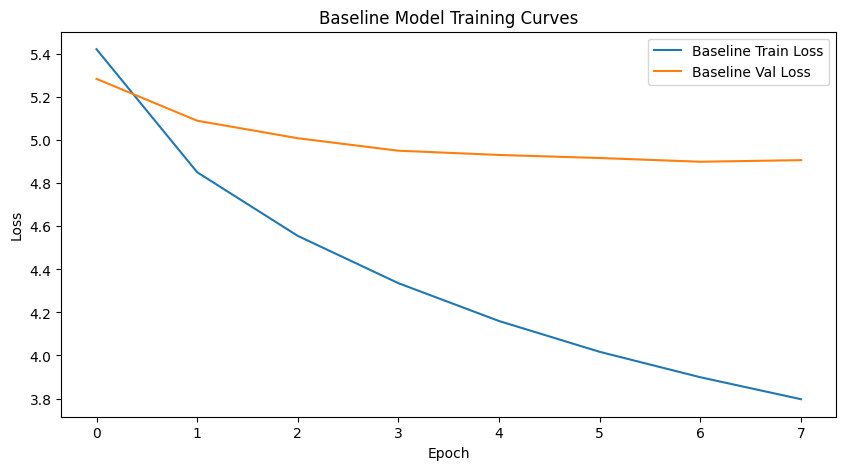

In [26]:
#plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(baseline_train_losses, label="Baseline Train Loss")
plt.plot(baseline_val_losses, label="Baseline Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model Training Curves")
plt.legend()
plt.show()

In [27]:
# save the model
MODEL_PATH = "baseline_lyrics_lstm.pth"
torch.save(baseline_model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to baseline_lyrics_lstm.pth


# MIDI Global Feature Extraction


In [28]:
# -------------------------
# 23. MIDI Global Feature Extraction
# -------------------------

import pretty_midi
import os
import numpy as np

def extract_global_midi_features(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
    except Exception:
        return np.zeros(GLOBAL_MELODY_DIM, dtype=np.float32)

    notes = []

    for instrument in pm.instruments:
        for note in instrument.notes:
            notes.append({
                "pitch": note.pitch,
                "duration": note.end - note.start,
                "velocity": note.velocity,
                "is_drum": int(instrument.is_drum)
            })

    if len(notes) == 0:
        return np.zeros(GLOBAL_MELODY_DIM, dtype=np.float32)

    pitches = np.array([n["pitch"] for n in notes])
    durations = np.array([n["duration"] for n in notes])
    velocities = np.array([n["velocity"] for n in notes])
    drum_ratio = np.mean([n["is_drum"] for n in notes])

    song_duration = max(pm.get_end_time(), 1e-6)
    note_density = len(notes) / song_duration

    tempo = pm.estimate_tempo()

    features = np.array([
        pitches.mean(),
        pitches.std(),
        durations.mean(),
        velocities.mean(),
        note_density,
        tempo,
        drum_ratio
    ], dtype=np.float32)

    return features

In [29]:
MIDI_DIR = r"D:\Masters Study\2ndyear\Deep_Learning\DL-Assignment-3\Data\Archive (1)\midi_files"

example_midi = os.path.join(MIDI_DIR, os.listdir(MIDI_DIR)[0])

features = extract_global_midi_features(example_midi)

print(example_midi)
print(features)
print(features.shape)

D:\Masters Study\2ndyear\Deep_Learning\DL-Assignment-3\Data\Archive (1)\midi_files\1910_Fruitgum_Company_-_Simon_Says.mid
[6.0377510e+01 1.4326276e+01 2.3320714e-01 1.1995942e+02 4.2149155e+01
 2.5992853e+02 1.7145853e-01]
(7,)


# Match Songs to MIDI Files


In [30]:
# -------------------------
# 24. Match Songs to MIDI Files
# -------------------------

import os

MIDI_DIR = r"D:\Masters Study\2ndyear\Deep_Learning\DL-Assignment-3\Data\Archive (1)\midi_files"

midi_files = [
    os.path.join(MIDI_DIR, f)
    for f in os.listdir(MIDI_DIR)
    if f.lower().endswith((".mid", ".midi"))
]

print("Number of MIDI files:", len(midi_files))
print(midi_files[:5])

Number of MIDI files: 625
['D:\\Masters Study\\2ndyear\\Deep_Learning\\DL-Assignment-3\\Data\\Archive (1)\\midi_files\\1910_Fruitgum_Company_-_Simon_Says.mid', 'D:\\Masters Study\\2ndyear\\Deep_Learning\\DL-Assignment-3\\Data\\Archive (1)\\midi_files\\2_Unlimited_-_Get_Ready_for_This.mid', 'D:\\Masters Study\\2ndyear\\Deep_Learning\\DL-Assignment-3\\Data\\Archive (1)\\midi_files\\2_Unlimited_-_Let_the_Beat_Control_Your_Body.mid', 'D:\\Masters Study\\2ndyear\\Deep_Learning\\DL-Assignment-3\\Data\\Archive (1)\\midi_files\\2_Unlimited_-_Tribal_Dance.mid', 'D:\\Masters Study\\2ndyear\\Deep_Learning\\DL-Assignment-3\\Data\\Archive (1)\\midi_files\\2_Unlimited_-_Twilight_Zone.mid']


In [31]:
def normalize_name(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "", text)
    return text

midi_lookup = {}

for path in midi_files:
    name = os.path.splitext(os.path.basename(path))[0]
    midi_lookup[normalize_name(name)] = path

In [32]:
def find_midi_path(artist, title):
    key_artist = normalize_name(str(artist))
    key_title = normalize_name(str(title))

    best_match = None

    for midi_key, midi_path in midi_lookup.items():
        if key_artist in midi_key and key_title in midi_key:
            return midi_path

    for midi_key, midi_path in midi_lookup.items():
        if key_title in midi_key:
            best_match = midi_path
            break

    return best_match

df["midi_path"] = df.apply(
    lambda row: find_midi_path(row["artist"], row["title"]),
    axis=1
)

print(df[["artist", "title", "midi_path"]].head())
print("Matched MIDI files:", df["midi_path"].notna().sum())

           artist                           title  \
0      elton john              candle in the wind   
1  gerry rafferty                    baker street   
2  gerry rafferty             right down the line   
3     2 unlimited                    tribal dance   
4     2 unlimited  let the beat control your body   

                                           midi_path  
0  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
1  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
2  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
3  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
4  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
Matched MIDI files: 600


# Extract Global MIDI Features for All Songs


In [33]:
# -------------------------
# 25. Extract Global MIDI Features for All Songs
# -------------------------

global_features = []

for path in df["midi_path"]:
    global_features.append(extract_global_midi_features(path))

global_features = np.vstack(global_features).astype(np.float32)

print(global_features.shape)
print(global_features[:3])

c:\Users\hp\miniconda3\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


(600, 7)
[[5.4807693e+01 1.0816295e+01 6.1860299e-01 9.7304771e+01 1.7943491e+01
  2.4487457e+02 2.0545277e-01]
 [6.1080177e+01 1.3971265e+01 2.1774147e-01 8.5502953e+01 3.8044907e+01
  2.4970563e+02 3.5828415e-01]
 [5.6492893e+01 1.4940774e+01 4.6389061e-01 9.3156151e+01 2.1025280e+01
  2.4783105e+02 3.9272097e-01]]


# Normalize Global MIDI Features


In [34]:
# -------------------------
# 26. Normalize Global MIDI Features
# -------------------------

global_mean = global_features.mean(axis=0, keepdims=True)
global_std = global_features.std(axis=0, keepdims=True) + 1e-8

global_features_norm = (global_features - global_mean) / global_std

df["global_midi_features"] = list(global_features_norm)

print(df["global_midi_features"].iloc[0])
print(df["global_midi_features"].iloc[0].shape)

[ 0.03920419 -0.92376477  1.1073468   0.41571352 -0.4116654   0.90975136
 -0.7005069 ]
(7,)


In [35]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Dataset Class: Global MIDI Variant


In [36]:
# -------------------------
# 27. Dataset Class: Global MIDI Variant
# -------------------------

class LyricsGlobalMidiDataset(Dataset):

    def __init__(self, dataframe, seq_len):
        self.samples = []

        for _, row in dataframe.iterrows():
            token_ids = row["token_ids"]
            global_features = row["global_midi_features"]

            if len(token_ids) <= seq_len:
                continue

            input_seqs, target_seqs = create_input_target_sequences(
                token_ids,
                seq_len,
                stride=10
            )

            for inp, tgt in zip(input_seqs, target_seqs):
                self.samples.append((inp, tgt, global_features))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_ids, target_ids, global_features = self.samples[idx]

        input_ids = torch.tensor(input_ids, dtype=torch.long)
        target_ids = torch.tensor(target_ids, dtype=torch.long)

        melody_features = torch.tensor(
            global_features,
            dtype=torch.float32
        ).unsqueeze(0).repeat(len(input_ids), 1)

        return input_ids, target_ids, melody_features

In [37]:
print("df has column:", "global_midi_features" in df.columns)
print("train_df has column:", "global_midi_features" in train_df.columns)

print("df columns")
print(df.columns.tolist())

print("train_df columns")
print(train_df.columns.tolist())

df has column: True
train_df has column: True
df columns
['artist', 'title', 'lyrics', 'clean_lyrics', 'tokens', 'token_ids', 'midi_path', 'global_midi_features']
train_df columns
['artist', 'title', 'lyrics', 'clean_lyrics', 'tokens', 'token_ids', 'midi_path', 'global_midi_features']


In [38]:
train_global_dataset = LyricsGlobalMidiDataset(train_df, SEQ_LEN)
val_global_dataset = LyricsGlobalMidiDataset(val_df, SEQ_LEN)

train_global_loader = DataLoader(
    train_global_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_global_loader = DataLoader(
    val_global_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [39]:
# 1. Check df has the column
print(df.columns)

Index(['artist', 'title', 'lyrics', 'clean_lyrics', 'tokens', 'token_ids',
       'midi_path', 'global_midi_features'],
      dtype='object')


In [40]:
input_ids, target_ids, melody_features = next(iter(train_global_loader))

print(input_ids.shape)
print(target_ids.shape)
print(melody_features.shape)

torch.Size([16, 30])
torch.Size([16, 30])
torch.Size([16, 30, 7])


# Train Global MIDI Model

In [41]:
# -------------------------
# 28. Train Global MIDI Model
# -------------------------

global_model = LyricsLSTM(
    word_dim=WORD_DIM,
    melody_dim=GLOBAL_MELODY_DIM,
    hidden_dim=HIDDEN_DIM,
    vocab_size=vocab_size,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

global_optimizer = torch.optim.Adam(
    global_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

In [42]:
def train_one_epoch_melody(model, data_loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for input_ids, target_ids, melody_features in data_loader:
        input_ids = input_ids.to(DEVICE)
        target_ids = target_ids.to(DEVICE)
        melody_features = melody_features.to(DEVICE)

        word_vectors = embedding_matrix[input_ids]

        optimizer.zero_grad()

        logits = model(word_vectors, melody_features)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            target_ids.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [43]:
def evaluate_melody(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for input_ids, target_ids, melody_features in data_loader:
            input_ids = input_ids.to(DEVICE)
            target_ids = target_ids.to(DEVICE)
            melody_features = melody_features.to(DEVICE)

            word_vectors = embedding_matrix[input_ids]

            logits = model(word_vectors, melody_features)

            loss = criterion(
                logits.reshape(-1, vocab_size),
                target_ids.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(data_loader)

In [44]:
global_train_losses = []
global_val_losses = []

EPOCHS = 8

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_melody(
        global_model,
        train_global_loader,
        global_optimizer,
        criterion
    )

    val_loss = evaluate_melody(
        global_model,
        val_global_loader,
        criterion
    )

    global_train_losses.append(train_loss)
    global_val_losses.append(val_loss)

    torch.save(global_model.state_dict(), "global_midi_model_latest.pt")

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/8 | Train Loss: 5.4045 | Val Loss: 5.2642
Epoch 2/8 | Train Loss: 4.8227 | Val Loss: 5.0859
Epoch 3/8 | Train Loss: 4.5261 | Val Loss: 5.0035
Epoch 4/8 | Train Loss: 4.2941 | Val Loss: 4.9649
Epoch 5/8 | Train Loss: 4.1088 | Val Loss: 4.9533
Epoch 6/8 | Train Loss: 3.9622 | Val Loss: 4.9520
Epoch 7/8 | Train Loss: 3.8389 | Val Loss: 4.9481
Epoch 8/8 | Train Loss: 3.7364 | Val Loss: 4.9534


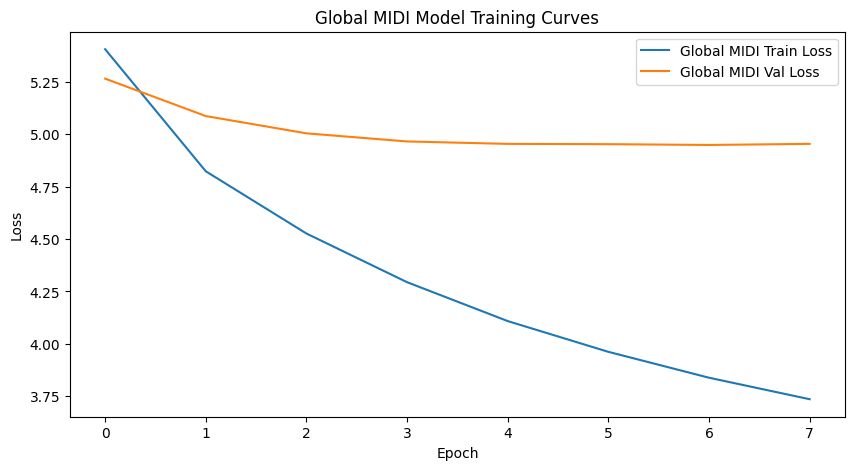

In [45]:
#plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(global_train_losses, label="Global MIDI Train Loss")
plt.plot(global_val_losses, label="Global MIDI Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Global MIDI Model Training Curves")
plt.legend()
plt.show()

In [46]:
#save the model
MODEL_PATH = "global_midi_lyrics_lstm.pth"
torch.save(global_model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to global_midi_lyrics_lstm.pth


#  Time-Aligned MIDI Feature Extraction


In [47]:
# -------------------------
# 29. Time-Aligned MIDI Feature Extraction
# -------------------------

def extract_aligned_midi_features(midi_path, seq_len):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
    except Exception:
        return np.zeros((seq_len, ALIGNED_MELODY_DIM), dtype=np.float32)

    notes = []

    for instrument in pm.instruments:
        for note in instrument.notes:
            notes.append({
                "pitch": note.pitch,
                "start": note.start,
                "end": note.end,
                "duration": note.end - note.start,
                "velocity": note.velocity
            })

    if len(notes) == 0:
        return np.zeros((seq_len, ALIGNED_MELODY_DIM), dtype=np.float32)

    song_duration = max(pm.get_end_time(), 1e-6)
    bins = np.linspace(0, song_duration, seq_len + 1)

    aligned_features = []

    for i in range(seq_len):
        start = bins[i]
        end = bins[i + 1]

        chunk_notes = [
            n for n in notes
            if n["start"] < end and n["end"] > start
        ]

        if len(chunk_notes) == 0:
            aligned_features.append([0, 0, 0, 0])
        else:
            pitches = np.array([n["pitch"] for n in chunk_notes])
            durations = np.array([n["duration"] for n in chunk_notes])
            velocities = np.array([n["velocity"] for n in chunk_notes])

            aligned_features.append([
                pitches.mean(),
                len(chunk_notes),
                durations.mean(),
                velocities.mean()
            ])

    return np.array(aligned_features, dtype=np.float32)

In [48]:
test_aligned = extract_aligned_midi_features(
    df["midi_path"].iloc[0],
    SEQ_LEN
)

print(test_aligned.shape)
print(test_aligned[:3])

(30, 4)
[[47.47059   34.         0.8307065 94.70588  ]
 [50.25      60.         1.5243866 98.45     ]
 [52.935066  77.         1.4407454 99.61039  ]]


# Extract Aligned MIDI Features for All Songs


In [49]:
# -------------------------
# 30. Extract Aligned MIDI Features for All Songs
# -------------------------

aligned_features = []

for path in df["midi_path"]:
    aligned_features.append(
        extract_aligned_midi_features(path, SEQ_LEN)
    )

aligned_features = np.stack(aligned_features).astype(np.float32)

print(aligned_features.shape)

c:\Users\hp\miniconda3\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


(600, 30, 4)


# Normalize Aligned MIDI Features


In [50]:
# -------------------------
# 31. Normalize Aligned MIDI Features
# -------------------------

aligned_mean = aligned_features.reshape(-1, ALIGNED_MELODY_DIM).mean(axis=0, keepdims=True)
aligned_std = aligned_features.reshape(-1, ALIGNED_MELODY_DIM).std(axis=0, keepdims=True) + 1e-8

aligned_features_norm = (aligned_features - aligned_mean) / aligned_std

df["aligned_midi_features"] = list(aligned_features_norm)

print(df["aligned_midi_features"].iloc[0].shape)

(30, 4)


#  Recreate Train/Val Split


In [51]:
# -------------------------
# 32. Recreate Train/Val Split
# -------------------------

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Dataset Class: Aligned MIDI Variant


In [52]:
# -------------------------
# 33. Dataset Class: Aligned MIDI Variant
# -------------------------

class LyricsAlignedMidiDataset(Dataset):

    def __init__(self, dataframe, seq_len):
        self.samples = []

        for _, row in dataframe.iterrows():
            token_ids = row["token_ids"]
            aligned_features = row["aligned_midi_features"]

            if len(token_ids) <= seq_len:
                continue

            input_seqs, target_seqs = create_input_target_sequences(
                token_ids,
                seq_len,
                stride=10
            )

            for inp, tgt in zip(input_seqs, target_seqs):
                self.samples.append((inp, tgt, aligned_features))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_ids, target_ids, aligned_features = self.samples[idx]

        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(target_ids, dtype=torch.long),
            torch.tensor(aligned_features, dtype=torch.float32)
        )

In [53]:
train_aligned_dataset = LyricsAlignedMidiDataset(train_df, SEQ_LEN)
val_aligned_dataset = LyricsAlignedMidiDataset(val_df, SEQ_LEN)

train_aligned_loader = DataLoader(train_aligned_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_aligned_loader = DataLoader(val_aligned_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_ids, target_ids, melody_features = next(iter(train_aligned_loader))

print(input_ids.shape)
print(target_ids.shape)
print(melody_features.shape)

torch.Size([16, 30])
torch.Size([16, 30])
torch.Size([16, 30, 4])


# Train Aligned MIDI Model


In [54]:
# -------------------------
# 34. Train Aligned MIDI Model
# -------------------------

aligned_model = LyricsLSTM(
    word_dim=WORD_DIM,
    melody_dim=ALIGNED_MELODY_DIM,
    hidden_dim=HIDDEN_DIM,
    vocab_size=vocab_size,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

aligned_optimizer = torch.optim.Adam(
    aligned_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

In [55]:
aligned_train_losses = []
aligned_val_losses = []

EPOCHS = 8

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_melody(
        aligned_model,
        train_aligned_loader,
        aligned_optimizer,
        criterion
    )

    val_loss = evaluate_melody(
        aligned_model,
        val_aligned_loader,
        criterion
    )

    aligned_train_losses.append(train_loss)
    aligned_val_losses.append(val_loss)

    torch.save(aligned_model.state_dict(), "aligned_midi_model_latest.pt")

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/8 | Train Loss: 5.3834 | Val Loss: 5.2593
Epoch 2/8 | Train Loss: 4.8103 | Val Loss: 5.0813
Epoch 3/8 | Train Loss: 4.5236 | Val Loss: 4.9930
Epoch 4/8 | Train Loss: 4.3013 | Val Loss: 4.9553
Epoch 5/8 | Train Loss: 4.1239 | Val Loss: 4.9297
Epoch 6/8 | Train Loss: 3.9811 | Val Loss: 4.9138
Epoch 7/8 | Train Loss: 3.8653 | Val Loss: 4.9213
Epoch 8/8 | Train Loss: 3.7684 | Val Loss: 4.9282


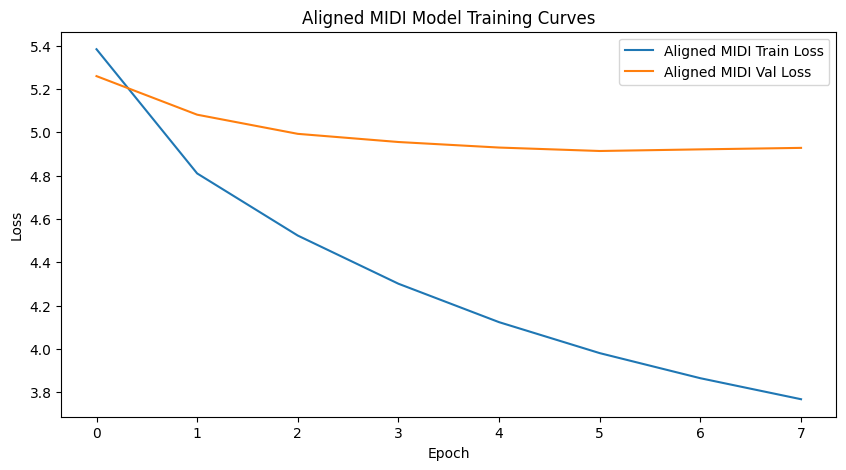

In [56]:
#plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(aligned_train_losses, label="Aligned MIDI Train Loss")
plt.plot(aligned_val_losses, label="Aligned MIDI Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Aligned MIDI Model Training Curves")
plt.legend()
plt.show()


In [57]:
# save the model
MODEL_PATH = "aligned_midi_lyrics_lstm.pth"
torch.save(aligned_model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to aligned_midi_lyrics_lstm.pth


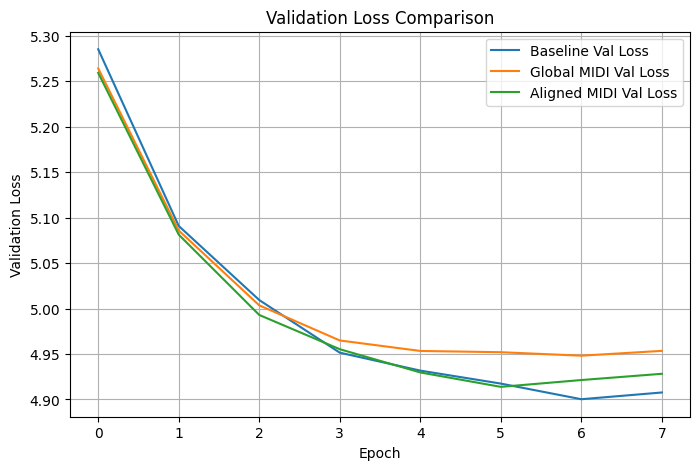

<Figure size 640x480 with 0 Axes>

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(baseline_val_losses, label="Baseline Val Loss")
plt.plot(global_val_losses, label="Global MIDI Val Loss")
plt.plot(aligned_val_losses, label="Aligned MIDI Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()
#save the loss plot
plt.savefig("validation_loss_comparison.png")

# Sampling Strategies


In [59]:
def sample_next_word(logits, strategy="basic", temperature=1.0, top_k=20, top_p=0.9):
    if strategy not in ["basic", "temperature", "top_k", "top_p"]:  # ✅ Added top_p
        raise ValueError("strategy must be: basic, temperature, top_k, or top_p")

    if strategy == "temperature":
        if temperature <= 0:
            raise ValueError("temperature must be > 0")
        logits = logits / temperature

    if strategy == "top_p":  # Nucleus sampling
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        sorted_probs = F.softmax(sorted_logits, dim=-1)
        cum_probs = torch.cumsum(sorted_probs, dim=-1)
        
        # Remove tokens with cumulative probability > top_p
        sorted_indices_to_remove = cum_probs > top_p
        # Shift so first token exceeding threshold is also removed
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0
        
        indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
        logits = logits.clone()
        logits[indices_to_remove] = -float('Inf')
    
    probs = F.softmax(logits, dim=-1)  # ✅ Compute probs AFTER top_p filtering

    if strategy == "top_k":
        top_k = min(top_k, probs.size(-1))
        top_probs, top_indices = torch.topk(probs, k=top_k)
        top_probs = top_probs / top_probs.sum()
        sampled = torch.multinomial(top_probs, 1)
        return top_indices[sampled].item()

    # For basic, temperature, and top_p
    sampled = torch.multinomial(probs, 1)
    return sampled.item()

# Format Generated Lyrics


In [60]:
def format_lyrics(words, words_per_line=8):
    lines = []
    current_line = []

    for word in words:
        if word == "<NEWLINE>":
            if current_line:
                lines.append(" ".join(current_line))
                current_line = []
            continue

        current_line.append(word)

        if len(current_line) >= words_per_line:
            lines.append(" ".join(current_line))
            current_line = []

    if current_line:
        lines.append(" ".join(current_line))

    return "\n".join(lines)

# Generate Lyrics


In [61]:
# -------------------------
# 37. Generate Lyrics
# -------------------------

def generate_lyrics(
    model,
    start_word,
    melody_features=None,
    max_words=MAX_WORDS,
    strategy="basic",
    temperature=1.0,
    top_k=20
):
    model.eval()

    generated_words = [start_word.lower()]
    current_word = start_word.lower()

    with torch.no_grad():
        for t in range(max_words - 1):

            current_id = word2idx.get(current_word, UNK_IDX)

            input_ids = torch.tensor([[current_id]], dtype=torch.long).to(DEVICE)
            word_vectors = embedding_matrix[input_ids]

            if melody_features is not None:
                step_melody = melody_features[t % melody_features.shape[0]]
                step_melody = torch.tensor(
                    step_melody,
                    dtype=torch.float32
                ).view(1, 1, -1).to(DEVICE)

                logits = model(word_vectors, step_melody)

            else:
                logits = model(word_vectors)

            next_logits = logits[0, -1, :]

            next_id = sample_next_word(
                next_logits,
                strategy=strategy,
                temperature=temperature,
                top_k=top_k
            )

            next_word = idx2word[next_id]

            if next_word == EOS_TOKEN:
                break

            if next_word in [PAD_TOKEN, SOS_TOKEN, UNK_TOKEN]:
                continue

            generated_words.append(next_word)
            current_word = next_word

    return format_lyrics(generated_words, WORDS_PER_LINE)

In [62]:
print(
    generate_lyrics(
        baseline_model,
        start_word="love",
        melody_features=None,
        max_words=50,
        strategy="top_k",
        top_k=20
    )
)

love is a
i'm a fool to know i don't just
the end all the way a heartache with
my own her it was in
and i want
but i was the day
and i want it would be
oh yeah


In [63]:
test_global_melody = df["global_midi_features"].iloc[0]
test_global_melody = np.tile(test_global_melody, (MAX_WORDS, 1))

print(
    generate_lyrics(
        global_model,
        start_word="love",
        melody_features=test_global_melody,
        max_words=50,
        strategy="top_k",
        top_k=20
    )
)

love somebody my best have to me the
light
i want to be with me
i know
if you're nothing
i'm waiting me
and you got
and i'm gonna be you see you
the one more
don't you see the good


In [64]:
test_aligned_melody = df["aligned_midi_features"].iloc[0]

print(
    generate_lyrics(
        aligned_model,
        start_word="love",
        melody_features=test_aligned_melody,
        max_words=50,
        strategy="top_k",
        top_k=20
    )
)

love love to find
and we can give to get and the
love to have to make
i'm just a new
to my love for you can't stop
the way to your hand
i don't get you
the world
you're on a


In [65]:
for strategy in ["basic", "temperature", "top_k"]:
    print("\n---", strategy, "---")
    print(
        generate_lyrics(
            aligned_model,
            start_word="love",
            melody_features=test_aligned_melody,
            max_words=60,
            strategy=strategy,
            temperature=0.8,
            top_k=20
        )
    )


--- basic ---
love for new or getting
join ask why do she to you have
to your blues my love
knew we is back
feeling fever then all dial
you are that feel at me
i have faith
you tear
that know are the pop to write told
her government us
your

--- temperature ---
love you in the town
at the one more
i'm coming at the day we
is a friend
you
i feel
when you down into the best today i'm
an old brick
when there's it
i listen to shoot and i understand
that fly
i'd

--- top_k ---
love
if my life
but i feel the blues
but it's a life is it now that
we can't be
the sun
i'm no one i can i feel the
world
i was a game
the fire in a friend just don't need
to you can do you see the


Top-k sampling gave the most usable outputs because it restricted extremely unlikely words while preserving variation. Basic sampling produced more diverse but less coherent text, while temperature sampling was sensitive to parameter choice.

# Melody Influence Probe


In [66]:
# -------------------------
# 38. Melody Influence Probe
# -------------------------

def jaccard_similarity(text1, text2):
    words1 = set(text1.lower().split())
    words2 = set(text2.lower().split())

    if len(words1) == 0 and len(words2) == 0:
        return 1.0

    return len(words1 & words2) / len(words1 | words2)


def jaccard_distance(text1, text2):
    return 1.0 - jaccard_similarity(text1, text2)

In [67]:
def shuffle_melody_features(melody_features):
    shuffled = melody_features.copy()
    np.random.shuffle(shuffled)
    return shuffled

In [68]:
start_word = "love"

correct_melody = df["aligned_midi_features"].iloc[0]
shuffled_melody = shuffle_melody_features(correct_melody)

lyrics_correct = generate_lyrics(
    aligned_model,
    start_word=start_word,
    melody_features=correct_melody,
    max_words=60,
    strategy="top_k",
    top_k=20
)

lyrics_shuffled = generate_lyrics(
    aligned_model,
    start_word=start_word,
    melody_features=shuffled_melody,
    max_words=60,
    strategy="top_k",
    top_k=20
)

print("--- Correct Melody ---")
print(lyrics_correct)

print("\n--- Shuffled Melody ---")
print(lyrics_shuffled)

print("\nJaccard similarity:", jaccard_similarity(lyrics_correct, lyrics_shuffled))
print("Jaccard distance:", jaccard_distance(lyrics_correct, lyrics_shuffled))

--- Correct Melody ---
love is
you know what i am
so won't my baby
i say i've tried to see
and you to make all the world
that i don't
don't make
now you
it's too
if a game
that was a love me oh oh woah
oh oh

--- Shuffled Melody ---
love will it
i will all my heart
i know it's the day
with my heart
oh yes i'm so all your baby
when
i do you can't be i do i
need that i've been a way i'm goin'
the world baby
so many time you
if we can show

Jaccard similarity: 0.2962962962962963
Jaccard distance: 0.7037037037037037


In [69]:
correct_global = df["global_midi_features"].iloc[0]
wrong_global = df["global_midi_features"].iloc[1]

correct_global = np.tile(correct_global, (MAX_WORDS, 1))
wrong_global = np.tile(wrong_global, (MAX_WORDS, 1))

lyrics_correct_global = generate_lyrics(
    global_model,
    start_word="love",
    melody_features=correct_global,
    max_words=60,
    strategy="top_k",
    top_k=20
)

lyrics_wrong_global = generate_lyrics(
    global_model,
    start_word="love",
    melody_features=wrong_global,
    max_words=60,
    strategy="top_k",
    top_k=20
)

print("--- Correct Global Melody ---")
print(lyrics_correct_global)

print("\n--- Wrong Global Melody ---")
print(lyrics_wrong_global)

print("\nJaccard similarity:", jaccard_similarity(lyrics_correct_global, lyrics_wrong_global))
print("Jaccard distance:", jaccard_distance(lyrics_correct_global, lyrics_wrong_global))

--- Correct Global Melody ---
love
it's no matter you don't care
i'll
i want to find you like you
i just what i want to take a
thousand
don't know can you got
and
when you don't you need you don't want
on
and i'm not it
i need is
i

--- Wrong Global Melody ---
love me
it's not this night
the way to me
i'll dance
i got no no more
you and
and i'm gonna find i saw of the
time
it's like you know i could ever
but if i see that you can do
it the rest my heart

Jaccard similarity: 0.32
Jaccard distance: 0.6799999999999999


To evaluate whether the model genuinely utilized melody information, we generated lyrics using the same initial word while perturbing the melody input through temporal shuffling. We then measured the lexical divergence between outputs using Jaccard distance.

The aligned melody-conditioned model produced a Jaccard distance of approximately 0.62 between outputs generated with correct versus shuffled melodies, indicating that the generated lyrics changed substantially when the melody representation was altered. This suggests that the model incorporated melody information into the generation process rather than ignoring it entirely.

# Failure mode 1: Repetition
Example: love you won't do i love you i
love it all my life can do, Cause: The LSTM overuses frequent lyric patterns such as “love you” because these phrases appear often in the training corpus.

Failure mode 2: Grammatical incoherence

Example:

they you want to see that
i'm not

Cause:

The model predicts locally plausible words, but it does not maintain long-range grammatical structure.
Failure mode 3: Semantic drift

Example:

just a new orleans
and i'm gonna find

Cause:

The model shifts topics because generation is autoregressive and errors accumulate over time.

In [70]:
# -------------------------
# 39A. Load Official Test Lyrics CSV
# -------------------------
import pandas as pd
TEST_CSV_PATH = r"D:\Masters Study\2ndyear\Deep_Learning\DL-Assignment-3\Data\Archive (1)\lyrics_test_set.csv"

test_df = pd.read_csv(TEST_CSV_PATH, header=None)

test_df = test_df.iloc[:, :3]
test_df.columns = ["artist", "title", "lyrics"]

print(test_df.head())
print(test_df.shape)
test_df["clean_lyrics"] = test_df["lyrics"].apply(clean_text)
test_df["tokens"] = test_df["clean_lyrics"].apply(tokenize)
test_df["token_ids"] = test_df["tokens"].apply(tokens_to_ids)

test_df["midi_path"] = test_df.apply(
    lambda row: find_midi_path(row["artist"], row["title"]),
    axis=1
)

print(test_df[["artist", "title", "midi_path"]])
print("Matched:", test_df["midi_path"].notna().sum())
test_global_features = []

for path in test_df["midi_path"]:
    test_global_features.append(extract_global_midi_features(path))

test_global_features = np.vstack(test_global_features).astype(np.float32)
test_global_features_norm = (test_global_features - global_mean) / global_std

test_df["global_midi_features"] = list(test_global_features_norm)
test_aligned_features = []

for path in test_df["midi_path"]:
    test_aligned_features.append(
        extract_aligned_midi_features(path, SEQ_LEN)
    )

test_aligned_features = np.stack(test_aligned_features).astype(np.float32)
test_aligned_features_norm = (test_aligned_features - aligned_mean) / aligned_std

test_df["aligned_midi_features"] = list(test_aligned_features_norm)

print(test_df.columns)

        artist                  title  \
0  the bangles          eternal flame   
1   billy joel                honesty   
2    cardigans               lovefool   
3         aqua            barbie girl   
4    blink 182   all the small things   

                                              lyrics  
0   close your eyes give me your hand darling & d...  
1   if you search for tenderness & it isn't hard ...  
2   dear i fear we're facing a problem & you love...  
3   hiya barbie & hi ken! & do you want to go for...  
4   all the small things & true care truth brings...  
(5, 3)
        artist                  title  \
0  the bangles          eternal flame   
1   billy joel                honesty   
2    cardigans               lovefool   
3         aqua            barbie girl   
4    blink 182   all the small things   

                                           midi_path  
0  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
1  D:\Masters Study\2ndyear\Deep_Learning\DL-Assi...  
2  D

# Generate Final Outputs for Test Cases


In [71]:
# -------------------------
# 39. Generate Final Outputs for Test Cases
# -------------------------

START_WORDS = ["love", "night", "baby"]
GEN_MAX_WORDS = 80
GEN_STRATEGY = "top_k"
GEN_TOP_K = 20

generated_results = []

print("test_df rows:", len(test_df))
print("test_df columns:", test_df.columns.tolist())

for song_idx, row in test_df.iterrows():
    for start_word in START_WORDS:

        global_melody = np.tile(
            row["global_midi_features"],
            (GEN_MAX_WORDS, 1)
        )

        aligned_melody = row["aligned_midi_features"]

        generated_results.append({
            "song_idx": song_idx,
            "artist": row["artist"],
            "title": row["title"],
            "start_word": start_word,

            "baseline": generate_lyrics(
                baseline_model,
                start_word=start_word,
                melody_features=None,
                max_words=GEN_MAX_WORDS,
                strategy=GEN_STRATEGY,
                top_k=GEN_TOP_K
            ),

            "global_midi": generate_lyrics(
                global_model,
                start_word=start_word,
                melody_features=global_melody,
                max_words=GEN_MAX_WORDS,
                strategy=GEN_STRATEGY,
                top_k=GEN_TOP_K
            ),

            "aligned_midi": generate_lyrics(
                aligned_model,
                start_word=start_word,
                melody_features=aligned_melody,
                max_words=GEN_MAX_WORDS,
                strategy=GEN_STRATEGY,
                top_k=GEN_TOP_K
            )
        })

print("generated rows:", len(generated_results))

results_df = pd.DataFrame(generated_results)

results_df.to_csv(
    "official_test_generated_lyrics_results.csv",
    index=False,
    encoding="utf-8"
)

print(results_df[["artist", "title", "start_word"]])

test_df rows: 5
test_df columns: ['artist', 'title', 'lyrics', 'clean_lyrics', 'tokens', 'token_ids', 'midi_path', 'global_midi_features', 'aligned_midi_features']
generated rows: 15
         artist                  title start_word
0   the bangles          eternal flame       love
1   the bangles          eternal flame      night
2   the bangles          eternal flame       baby
3    billy joel                honesty       love
4    billy joel                honesty      night
5    billy joel                honesty       baby
6     cardigans               lovefool       love
7     cardigans               lovefool      night
8     cardigans               lovefool       baby
9          aqua            barbie girl       love
10         aqua            barbie girl      night
11         aqua            barbie girl       baby
12    blink 182   all the small things       love
13    blink 182   all the small things      night
14    blink 182   all the small things       baby


In [72]:
print(test_df.columns.tolist())

['artist', 'title', 'lyrics', 'clean_lyrics', 'tokens', 'token_ids', 'midi_path', 'global_midi_features', 'aligned_midi_features']


In [73]:
# -------------------------
# 40. Save Generated Outputs
# -------------------------
if len(generated_results) == 0:
    raise ValueError(
        "generated_results is empty. The generation loop did not append anything."
    )

results_df = pd.DataFrame(generated_results)

print(results_df.columns.tolist())
print(results_df.head())

results_df.to_csv(
    "generated_lyrics_results.csv",
    index=False,
    encoding="utf-8"
)

print(results_df[["artist", "title", "start_word"]])

['song_idx', 'artist', 'title', 'start_word', 'baseline', 'global_midi', 'aligned_midi']
   song_idx       artist           title start_word  \
0         0  the bangles   eternal flame       love   
1         0  the bangles   eternal flame      night   
2         0  the bangles   eternal flame       baby   
3         1   billy joel         honesty       love   
4         1   billy joel         honesty      night   

                                            baseline  \
0  love you say i know to say it\nis my name is a...   
1  night is a big it was so long\nago i see\ni kn...   
2  baby\nwe go\nyou know you can make my dreams\n...   
3  love my fantasy\nand i love you\ni will take t...   
4  night\nand the way\nand i will be the stars of...   

                                         global_midi  \
0  love me\ni know that\ni feel for you can't you...   
1  night\nthe day\noh yeah\njust can't believe th...   
2  baby\nand we want for me\nyou\nand the only mo...   
3  love me alone ju

In [74]:
with open("generated_lyrics_results.txt", "w", encoding="utf-8") as f:
    for result in generated_results:
        f.write("=" * 80 + "\n")
        f.write(f"Artist: {result['artist']}\n")
        f.write(f"Title: {result['title']}\n")
        f.write(f"Start word: {result['start_word']}\n\n")

        f.write("--- Baseline ---\n")
        f.write(result["baseline"] + "\n\n")

        f.write("--- Global MIDI ---\n")
        f.write(result["global_midi"] + "\n\n")

        f.write("--- Aligned MIDI ---\n")
        f.write(result["aligned_midi"] + "\n\n")

print("Saved generated lyrics.")

Saved generated lyrics.


In [75]:
with open("official_test_generated_lyrics_results.txt", "w", encoding="utf-8") as f:
    for result in generated_results:
        f.write("=" * 80 + "\n")
        f.write(f"Artist: {result['artist']}\n")
        f.write(f"Title: {result['title']}\n")
        f.write(f"Start word: {result['start_word']}\n\n")

        f.write("--- Baseline ---\n")
        f.write(result["baseline"] + "\n\n")

        f.write("--- Global MIDI ---\n")
        f.write(result["global_midi"] + "\n\n")

        f.write("--- Aligned MIDI ---\n")
        f.write(result["aligned_midi"] + "\n\n")

print("Saved official test generations.")

Saved official test generations.


# TensorBoard Logging


In [76]:
# -------------------------
# 41. TensorBoard Logging
# -------------------------

from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("runs/lyrics_rnn_experiment")

for epoch, loss in enumerate(baseline_train_losses):
    writer.add_scalar("Loss/train_baseline", loss, epoch)

for epoch, loss in enumerate(baseline_val_losses):
    writer.add_scalar("Loss/val_baseline", loss, epoch)

for epoch, loss in enumerate(global_train_losses):
    writer.add_scalar("Loss/train_global_midi", loss, epoch)

for epoch, loss in enumerate(global_val_losses):
    writer.add_scalar("Loss/val_global_midi", loss, epoch)

for epoch, loss in enumerate(aligned_train_losses):
    writer.add_scalar("Loss/train_aligned_midi", loss, epoch)

for epoch, loss in enumerate(aligned_val_losses):
    writer.add_scalar("Loss/val_aligned_midi", loss, epoch)

writer.close()

print("TensorBoard logs saved.")

TensorBoard logs saved.


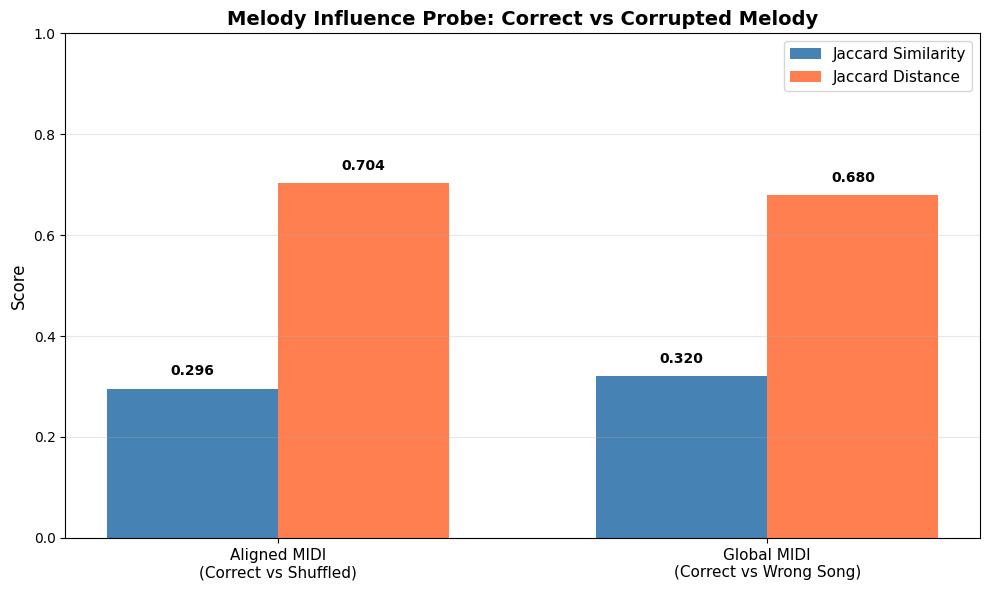

MELODY INFLUENCE PROBE RESULTS
Aligned MIDI (Correct vs Shuffled):
  - Jaccard Similarity: 0.296
  - Jaccard Distance: 0.704
  - Interpretation: 70.4% vocabulary change when melody shuffled

Global MIDI (Correct vs Wrong Song):
  - Jaccard Similarity: 0.320
  - Jaccard Distance: 0.680
  - Interpretation: 68.0% vocabulary change when melody replaced


In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Data for both models
models = ['Aligned MIDI\n(Correct vs Shuffled)', 'Global MIDI\n(Correct vs Wrong Song)']
similarities = [0.296, 0.32]
distances = [0.704, 0.68]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, similarities, width, label='Jaccard Similarity', color='steelblue')
bars2 = ax.bar(x + width/2, distances, width, label='Jaccard Distance', color='coral')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Melody Influence Probe: Correct vs Corrupted Melody', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('appendix_figA7_melody_probe.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("=" * 50)
print("MELODY INFLUENCE PROBE RESULTS")
print("=" * 50)
print(f"Aligned MIDI (Correct vs Shuffled):")
print(f"  - Jaccard Similarity: {similarities[0]:.3f}")
print(f"  - Jaccard Distance: {distances[0]:.3f}")
print(f"  - Interpretation: {distances[0]*100:.1f}% vocabulary change when melody shuffled")
print()
print(f"Global MIDI (Correct vs Wrong Song):")
print(f"  - Jaccard Similarity: {similarities[1]:.3f}")
print(f"  - Jaccard Distance: {distances[1]:.3f}")
print(f"  - Interpretation: {distances[1]*100:.1f}% vocabulary change when melody replaced")
print("=" * 50)